In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, classification_report, accuracy_score


In [27]:
# Load the dataset
data = pd.read_csv(r"C:\Users\Nishanth\Downloads\surat_house_price.csv")

# Display initial rows
print(data.head())

numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mean())  # Avoiding inplace modification

# Fill missing values for categorical columns with mode
categorical_columns = data.select_dtypes(include=['object']).columns
for col in categorical_columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0])

data


                                       property_name areaWithType square_feet  \
0          2 BHK Apartment for Sale in Dindoli Surat  Carpet Area    644 sqft   
1           2 BHK Apartment for Sale in Althan Surat   Super Area   1278 sqft   
2          2 BHK Apartment for Sale in Pal Gam Surat   Super Area   1173 sqft   
3     2 BHK Apartment for Sale in Jahangirabad Surat  Carpet Area    700 sqft   
4  2 BHK Apartment for Sale in Orchid Fantasia, P...   Super Area   1250 sqft   

       transaction            status        floor      furnishing  \
0     New Property  Poss. by Oct '24  5 out of 10     Unfurnished   
1     New Property  Poss. by Jan '26  6 out of 14     Unfurnished   
2           Resale     Ready to Move  5 out of 13  Semi-Furnished   
3     New Property     Ready to Move  6 out of 14     Unfurnished   
4  Orchid Fantasia      New Property  Unfurnished               2   

        facing                                        description  \
0         West  Luxury projec

,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price
0,2 BHK Apartment for Sale in Dindoli Surat,Carpet Area,644 sqft,New Property,Poss. by Oct '24,5 out of 10,Unfurnished,West,"Luxury project with basement parking, Solar ro...","₹2,891 per sqft",₹33.8 Lac
1,2 BHK Apartment for Sale in Althan Surat,Super Area,1278 sqft,New Property,Poss. by Jan '26,6 out of 14,Unfurnished,South -West,2 And 3 BHK Luxurious Flat for Sell In New Alt...,"₹3,551 per sqft",₹45.4 Lac
2,2 BHK Apartment for Sale in Pal Gam Surat,Super Area,1173 sqft,Resale,Ready to Move,5 out of 13,Semi-Furnished,East,This affordable 2 BHK flat is situated along a...,"₹3,800 per sqft",₹44.6 Lac
3,2 BHK Apartment for Sale in Jahangirabad Surat,Carpet Area,700 sqft,New Property,Ready to Move,6 out of 14,Unfurnished,East,2 BHK Flat For sell IN Jahangirabad Prime Loca...,"₹3,966 per sqft",₹47 Lac
4,"2 BHK Apartment for Sale in Orchid Fantasia, P...",Super Area,1250 sqft,Orchid Fantasia,New Property,Unfurnished,2,2,"Multistorey Apartment for Sale in Palanpur, Su...","₹3,600 per sqft",₹45 Lac
...,...,...,...,...,...,...,...,...,...,...,...
4520,6 BHK Apartment for Sale in Millionaires Lifes...,Carpet Area,2000 sqft,New Property,Poss. by Dec '26,5 out of 12,Unfurnished,South - East,"Check out Millionaires Lifestyle in Vesu, one ...","₹5,000 per sqft",Call for Price
4521,"4 BHK Apartment for Sale in Savan Superia, Alt...",Super Area,3600 sqft,New Property,Poss. by Dec '25,5 out of 16,Unfurnished,South - East,Superia is a premium residential project launc...,"₹5,000 per sqft",Call for Price
4522,5 BHK Apartment for Sale in Roongta Green Vall...,Carpet Area,2250 sqft,New Property,Poss. by Dec '25,7 out of 13,Unfurnished,North - East,"When it comes to beautiful homes, nothing beat...","₹5,000 per sqft",Call for Price
4523,"6 BHK Apartment for Sale in Cellestial Dreams,...",Carpet Area,3450 sqft,New Property,Ready to Move,7 out of 18,Unfurnished,North - West,"DRB Ravani Cellestial Dreams in Vesu, Surat is...","₹5,000 per sqft",Call for Price


C:\Users\Nishanth\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


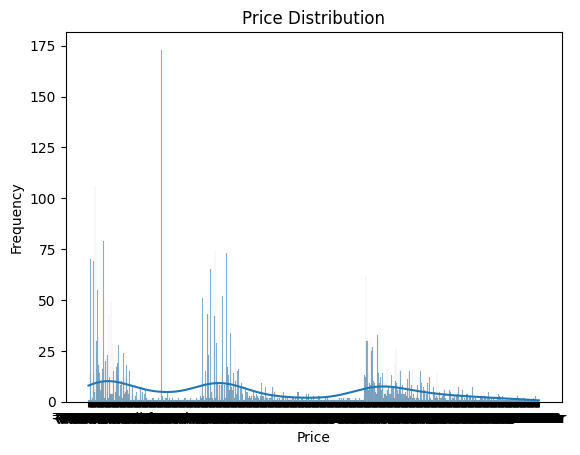

In [31]:
# Ensure the column exists
if 'price' in data.columns:
    # Plot distribution of the Price column
    sns.histplot(data['price'], kde=True)
    plt.title("Price Distribution")
    plt.xlabel("Price")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("The 'Price' column is not present in the dataset.")


In [17]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = r"C:\Users\Nishanth\Downloads\surat_house_price.csv"  # Replace with the correct file path
df = pd.read_csv(file_path)

# -----------------------------
# 1. BASIC EXPLORATION
# -----------------------------
# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(df.head())

# Basic information about the dataset
print("\nDataset Info:")
print(df.info())

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Basic statistics
print("\nStatistical summary of numerical columns:")
print(df.describe())

# -----------------------------
# 2. EDA
# -----------------------------
# Check the distribution of numerical features
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

# Correlation heatmap to analyze relationships between numerical variables
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Boxplots to detect outliers
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Analyze categorical features
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

# Pair plot (for numerical features with high correlation)
sns.pairplot(df[numerical_columns])
plt.show()

# -----------------------------
# 3. FEATURE ENGINEERING
# -----------------------------
# Handle missing values
# Replace missing numerical values with the median
for col in numerical_columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Replace missing categorical values with the mode
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Encoding categorical features
# Use one-hot encoding or label encoding
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Feature scaling (optional, if required)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Display the final dataset
print("\nDataset after Feature Engineering:")
print(df.head())

# -----------------------------
# 4. PREDICTION ANALYSIS
# -----------------------------
# Separate features and target
# Replace "TargetColumn" with the actual name of the column you want to predict
target_column = "TargetColumn"  # Replace with the target column
if target_column in df.columns:
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    # Split the data into training and testing sets
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train a simple regression or classification model (based on the target type)
    from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
    
    if y.nunique() > 10:  # Assuming more than 10 unique values means regression
        model = RandomForestRegressor(random_state=42)
    else:
        model = RandomForestClassifier(random_state=42)
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Evaluate the model
    print("\nModel Performance:")
    print("Training Score:", model.score(X_train, y_train))
    print("Testing Score:", model.score(X_test, y_test))
else:
    print("Target column not found. Please specify the column you want to predict.")

# -----------------------------
# Save the cleaned dataset
# -----------------------------
df.to_csv("cleaned_dataset.csv", index=False)
print("\nCleaned dataset saved as 'cleaned_dataset.csv'")


First few rows of the dataset:
                                       property_name areaWithType square_feet  \
0          2 BHK Apartment for Sale in Dindoli Surat  Carpet Area    644 sqft   
1           2 BHK Apartment for Sale in Althan Surat   Super Area   1278 sqft   
2          2 BHK Apartment for Sale in Pal Gam Surat   Super Area   1173 sqft   
3     2 BHK Apartment for Sale in Jahangirabad Surat  Carpet Area    700 sqft   
4  2 BHK Apartment for Sale in Orchid Fantasia, P...   Super Area   1250 sqft   

       transaction            status        floor      furnishing  \
0     New Property  Poss. by Oct '24  5 out of 10     Unfurnished   
1     New Property  Poss. by Jan '26  6 out of 14     Unfurnished   
2           Resale     Ready to Move  5 out of 13  Semi-Furnished   
3     New Property     Ready to Move  6 out of 14     Unfurnished   
4  Orchid Fantasia      New Property  Unfurnished               2   

        facing                                        description  

ValueError: could not convert string to float: '2 BHK Apartment for Sale in Dindoli Surat'

<Figure size 1000x800 with 0 Axes>

In [33]:
# Splitting the property_name column
data[['type', 'city']] = data['property_name'].str.extract(r'(.*?) for Sale in (.*)')

# Displaying the updated DataFrame
print(data)

                                          property_name areaWithType  \
0             2 BHK Apartment for Sale in Dindoli Surat  Carpet Area   
1              2 BHK Apartment for Sale in Althan Surat   Super Area   
2             2 BHK Apartment for Sale in Pal Gam Surat   Super Area   
3        2 BHK Apartment for Sale in Jahangirabad Surat  Carpet Area   
4     2 BHK Apartment for Sale in Orchid Fantasia, P...   Super Area   
...                                                 ...          ...   
4520  6 BHK Apartment for Sale in Millionaires Lifes...  Carpet Area   
4521  4 BHK Apartment for Sale in Savan Superia, Alt...   Super Area   
4522  5 BHK Apartment for Sale in Roongta Green Vall...  Carpet Area   
4523  6 BHK Apartment for Sale in Cellestial Dreams,...  Carpet Area   
4524  4 BHK Apartment for Sale in Roongta Green Vall...   Super Area   

     square_feet      transaction            status        floor  \
0       644 sqft     New Property  Poss. by Oct '24  5 out of 10   


Unique values in 'furnishing':
['Unfurnished' 'Semi-Furnished' '2' 'Anand Aspire' 'East' '1' 'Furnished'
 nan '3' '1 Covered,' '2 Covered' '1 Covered' 'Freehold' 'West'
 '26 Covered' 'Main Road' 'No' 'North' '1 Open' '6' 'Co-operative Society'
 '> 10' '4' 'Nilkanth Seven Homes' 'Aagam Navkar' '10 Open'
 'Vinayak Enclave' '5 Covered,' 'South -West'
 'Pool, Garden/Park, Main Road' 'Garden/Park, Main Road' '7 m' '30 m'
 '50 Covered,' 'South' '12 m' 'Yes' 'Gruham Luxuria' '2 Covered,' 'Congo'
 'Prayosha Shine' 'North - East' 'Vaishnodevi Ideal Homes' 'Santvan Lexon'
 'Sangini Epitome' '100 Covered' 'Nirvana Gladiolus' '7' '5 Covered' '5'
 'Raghuvir Spalex' '50 Open' 'South - East' 'North - West' '20 m'
 '20 Open' 'Garden/Park' '10 m' 'Sattvam' 'Pramukh Amaya' 'Sun Sarvam'
 '3 Covered' '2 Open' '6 m' 'Avadh Kimberly' 'Happy Glorious' 'DMD Aura'
 'Freedom Tower' '15 m' 'Surya Signature' 'Someshwara Enclave'
 'Green Valley Row House' 'Green Valley' 'Vatsalya Bungalows' 'DMD Signus'
 '10 Cove

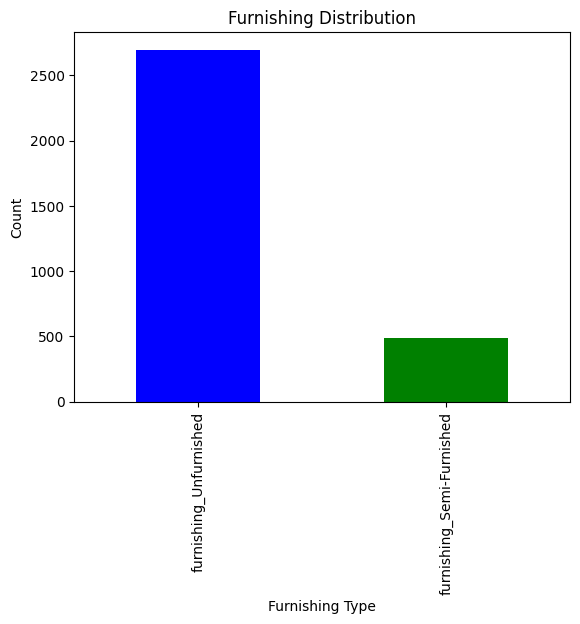


Furnishing column distribution (after cleaning):
furnishing_Unfurnished       2697
furnishing_Semi-Furnished     491
dtype: int64

Final cleaned dataset saved as 'cleaned_surat_house_price_final.csv'.


In [37]:
# Load the dataset
import pandas as pd
file_path = r"C:\Users\Nishanth\Downloads\surat_house_price.csv"  # Update with the correct file path
df = pd.read_csv(file_path)

# -----------------------------
# 1. SPLIT THE PROPERTY COLUMN
# -----------------------------
# Assuming the property column has values like "Apartment - City Name"
if 'property' in df.columns:
    df[['apartment', 'city']] = df['property'].str.split(' - ', expand=True)
    df.drop(columns=['property'], inplace=True)  # Drop the original property column
    print("\nSplit 'property' column into 'apartment' and 'city'.")

# -----------------------------
# 2. HANDLE FURNISHING COLUMN
# -----------------------------
# Check unique values in the furnishing column
if 'furnishing' in df.columns:
    print("\nUnique values in 'furnishing':")
    print(df['furnishing'].unique())

    # Separate rows with numerical values in the furnishing column
    invalid_rows = df[df['furnishing'].apply(lambda x: str(x).isdigit())]
    print(f"\nRows with invalid numerical values in 'furnishing':\n{invalid_rows}")

    # Replace numerical values in furnishing with the mode of the column
    mode_value = df['furnishing'][~df['furnishing'].apply(lambda x: str(x).isdigit())].mode()[0]
    df['furnishing'] = df['furnishing'].apply(lambda x: mode_value if str(x).isdigit() else x)

    # Encode the furnishing column using one-hot encoding
    df = pd.get_dummies(df, columns=['furnishing'], drop_first=True)
    print("\nCleaned and encoded the 'furnishing' column.")

# -----------------------------
# OPTIONAL: CONTINUE WITH OTHER CLEANING STEPS FROM THE ORIGINAL CODE
# -----------------------------
# (Handling missing values, outliers, feature engineering as before)

# Save the updated dataset
updated_file_path = "updated_surat_house_price.csv"
df.to_csv(updated_file_path, index=False)
print(f"\nUpdated dataset saved as '{updated_file_path}'.")

# -----------------------------
# PERFORM EDA ON FURNISHING
# -----------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the distribution of the furnishing column after cleaning
if 'furnishing_Unfurnished' in df.columns:  # Assuming one-hot encoding was applied
    furnishing_counts = df[['furnishing_Unfurnished', 'furnishing_Semi-Furnished']].sum()
    furnishing_counts.plot(kind='bar', color=['blue', 'green'])
    plt.title('Furnishing Distribution')
    plt.xlabel('Furnishing Type')
    plt.ylabel('Count')
    plt.show()

# Summary of the furnishing column
print("\nFurnishing column distribution (after cleaning):")
print(df[['furnishing_Unfurnished', 'furnishing_Semi-Furnished']].sum())

# Save the cleaned and processed dataset
cleaned_file_path = "cleaned_surat_house_price_final.csv"
df.to_csv(cleaned_file_path, index=False)
print(f"\nFinal cleaned dataset saved as '{cleaned_file_path}'.")
